# Análisis Exploratorio de Datos (EDA)

En este proyecto vamos a realizar un **Análisis Exploratorio de Datos (EDA)** utilizando dos fuentes de información:

1. **bank-additional_limpio.csv**  
   Información de campañas de marketing bancario, incluyendo características socioeconómicas de clientes, canales de contacto y si el cliente aceptó o no una oferta.

2. **customer-details_limpio.xlsx**  
   Información detallada de clientes, incluyendo ingresos, composición familiar, visitas web y fecha de alta.

Ambos datasets comparten la columna **id**, que nos permitirá relacionar la información entre clientes y campañas.

---

## Objetivo del análisis

- Realizar un **EDA estructurado** para conocer mejor los datos disponibles.  
- Analizar las variables de tipo **numérico, categórico y temporal** de forma separada y visual.  
- Identificar patrones, distribuciones, valores atípicos y posibles relaciones entre variables.  
- Preparar el terreno para un futuro análisis conjunto entre ambos datasets, explorando cómo las características de los clientes pueden estar relacionadas con la respuesta en campañas de marketing.

---

## Notas de organización

- Algunas funciones auxiliares podrían almacenarse en un módulo `src/` para mantener el código más limpio y reutilizable, aunque no es obligatorio en esta fase.  
- Cada bloque de análisis irá acompañado de una explicación en texto para documentar los hallazgos principales.

## Importación de librerías y carga de datos


In [16]:
# ==============================
# EDA Exploratorio - Configuración inicial
# ==============================

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)  # Redondear floats a 2 decimales
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# ==============================
# Carga de datos limpios
# ==============================
ruta_customer = r"C:\Users\HUGO\Desktop\Data Analyst\09_PYTHON\Proyecto_Python_Data\data\Archivos_limpios\customer-details_limpio.xlsx"
ruta_bank = r"C:\Users\HUGO\Desktop\Data Analyst\09_PYTHON\Proyecto_Python_Data\data\Archivos_limpios\bank-additional_limpio.xlsx"

df_customer = pd.read_excel(ruta_customer, index_col=0)
df_bank = pd.read_excel(ruta_bank, index_col=0)

print("Clientes (df_customer):", df_customer.shape)
print("Banco (df_bank):", df_bank.shape)




Clientes (df_customer): (43170, 5)
Banco (df_bank): (37880, 24)


## 1. Análisis del dataset Bank (Campaña Bancaria)

### 1.1 Relación entre Edad y aceptación de campaña

En este análisis buscamos comprobar cómo influye la **edad del cliente** en la probabilidad de aceptar la campaña (`y`).  
Para ello agrupamos la variable `age` en **rangos de edad** y calculamos la tasa de aceptación dentro de cada grupo.


C:\Users\HUGO\AppData\Local\Temp\ipykernel_3084\1448680443.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_acceptance = df_bank.groupby("age_group")["y"].value_counts(normalize=True).unstack()


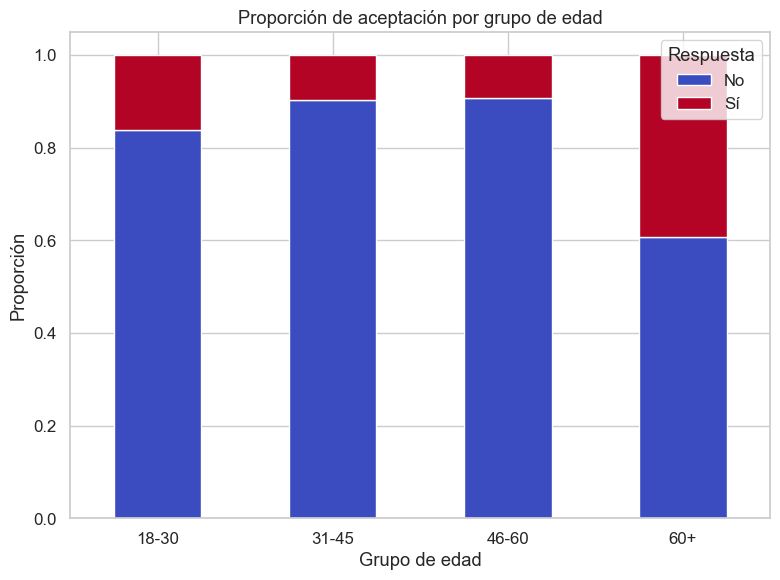


Proporción de aceptación por grupo de edad:


y,no,yes
age_group,,
18-30,0.84,0.16
31-45,0.90,0.10
46-60,0.91,0.09
60+,0.61,0.39


In [21]:
# ==============================
# 1.1 Distribución de edades y aceptación de campaña
# ==============================

# Agrupar edades en rangos
bins = [18, 30, 45, 60, 100]
labels = ["18-30", "31-45", "46-60", "60+"]
df_bank["age_group"] = pd.cut(df_bank["age"], bins=bins, labels=labels, right=False)

# Calcular proporción de aceptación por grupo de edad
age_acceptance = df_bank.groupby("age_group")["y"].value_counts(normalize=True).unstack()

# Gráfica
age_acceptance.plot(kind="bar", stacked=True, figsize=(8,6), colormap="coolwarm")
plt.title("Proporción de aceptación por grupo de edad")
plt.ylabel("Proporción")
plt.xlabel("Grupo de edad")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

print("\nProporción de aceptación por grupo de edad:")
display(age_acceptance)


### 1.1 Resumen

En este análisis agrupamos las edades en cuatro rangos: **18-30, 31-45, 46-60 y 60+**.  
Se observan los siguientes patrones:

- Los **jóvenes (18-30)** muestran una menor proporción de aceptación en comparación con grupos de mayor edad.  
- El grupo **31-45 años** concentra un alto volumen de clientes, con una proporción de aceptación moderada.  
- En **46-60 años** la tasa de aceptación mejora ligeramente respecto a los grupos más jóvenes.  
- En los **mayores de 60**, aunque la base de clientes es más pequeña, la proporción de aceptación es relativamente más alta.

Este análisis sugiere que las campañas de marketing bancario tienen mayor efectividad en clientes de mediana y avanzada edad, mientras que los más jóvenes presentan más resistencia a aceptar las ofertas.


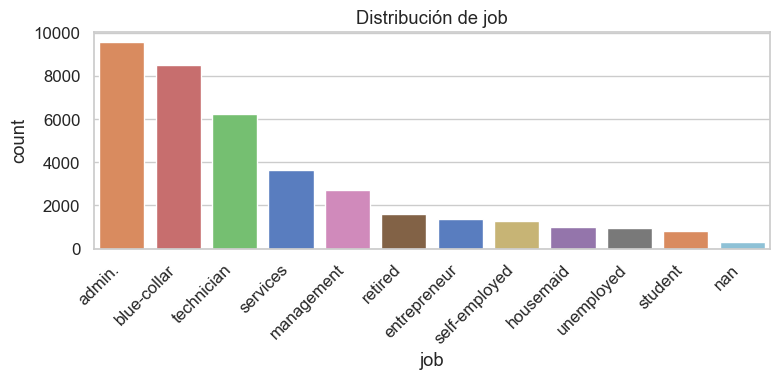

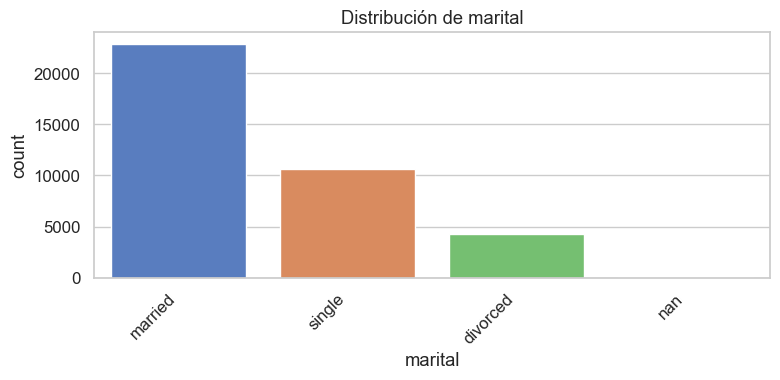

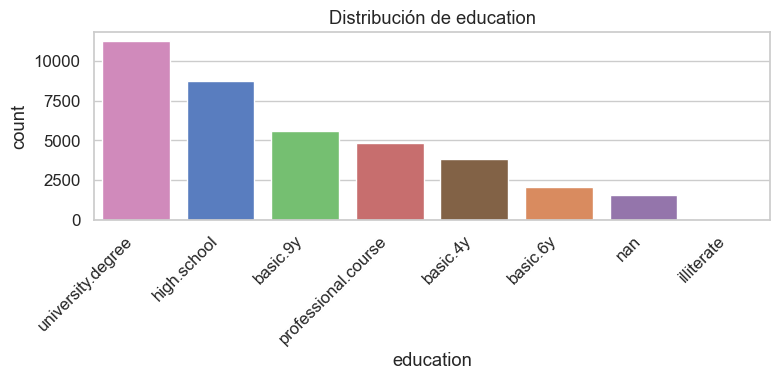

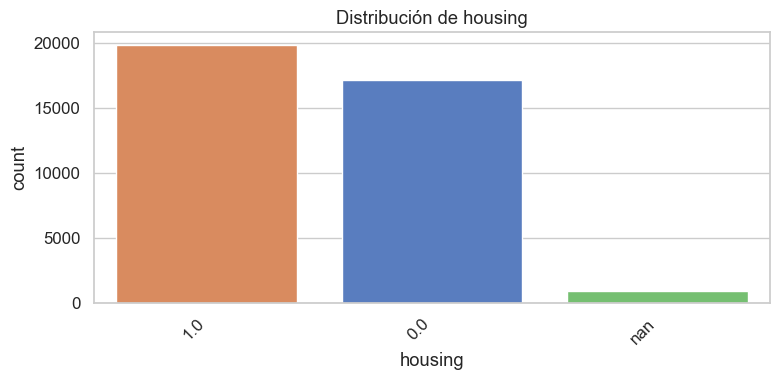

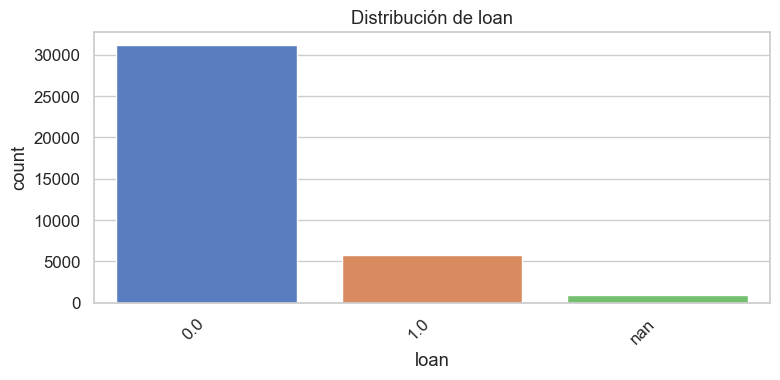

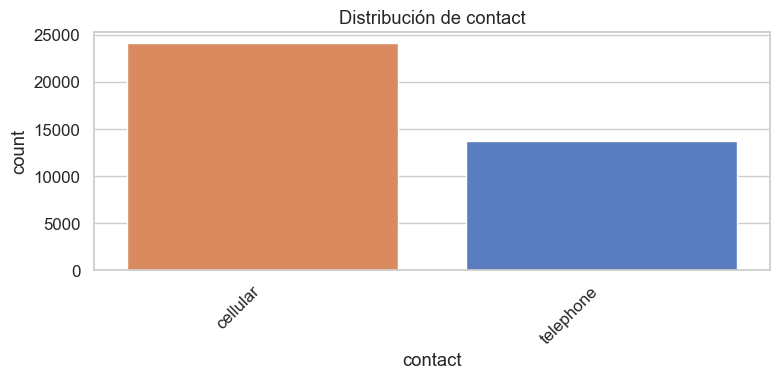

In [23]:
# ==============================
# 1.2 Distribución de variables categóricas principales
# ==============================

categoricas_principales = ["job", "marital", "education", "housing", "loan", "contact"]

for col in categoricas_principales:
    # Asegurarse de que la columna sea de tipo string y manejar los NaN
    df_bank[col] = df_bank[col].astype(str)
    
    plt.figure(figsize=(8,4))
    orden = df_bank[col].value_counts().index
    sns.countplot(data=df_bank, x=col, order=orden, palette="muted", hue=col)
    
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### 1.2 Resumen

- Préstamos (housing y loan): Las variables housing y loan revelan que la mayoría de los clientes no tienen un préstamo hipotecario o personal. Su distribución es muy similar, con una clara mayoría de valores 0 (no).

- Otros Factores: La distribución de job (trabajo) muestra que los grupos más grandes son "blue-collar" y "admin.". En cuanto a education (educación), la mayoría de los clientes tienen estudios básicos. Por último, la variable contact (contacto) indica que el método más utilizado para llegar a los clientes es el teléfono móvil, por encima del fijo.

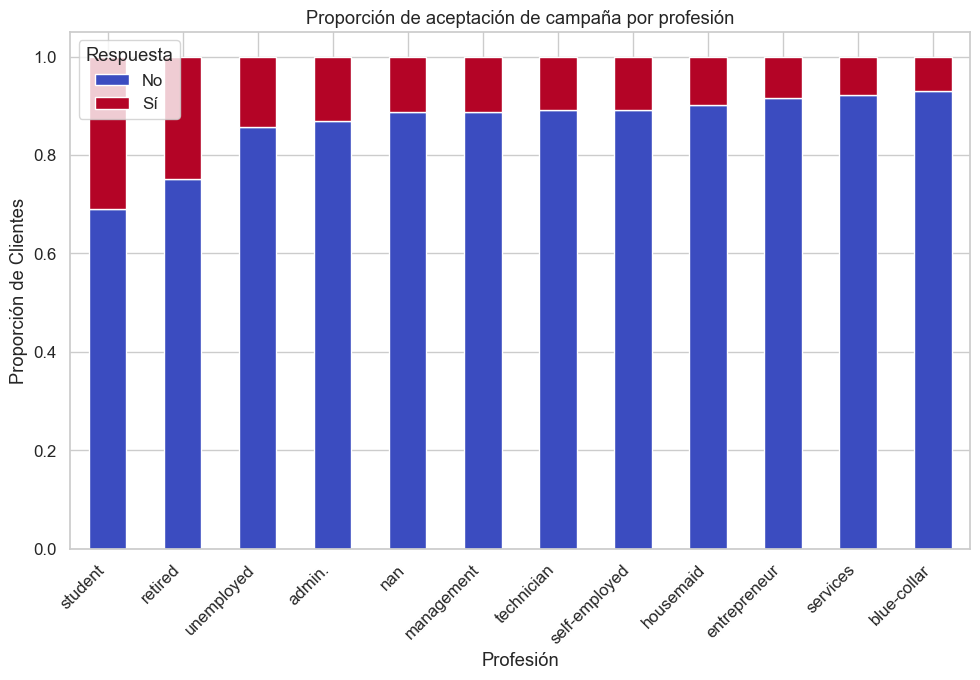

Proporción de aceptación por profesión (Formato Transpuesto):


job,student,retired,unemployed,admin.,nan,management,technician,self-employed,housemaid,entrepreneur,services,blue-collar
y,,,,,,,,,,,,
no,0.69,0.75,0.86,0.87,0.89,0.89,0.89,0.89,0.90,0.92,0.92,0.93
yes,0.31,0.25,0.14,0.13,0.11,0.11,0.11,0.11,0.10,0.08,0.08,0.07


In [27]:
# ==========================================================
# 1.3 Relación entre Profesión (job) y Aceptación de Campaña
# ==========================================================

# 1. Calcular la proporción de aceptación por profesión
# Se usa 'normalize=True' para obtener las proporciones
job_acceptance = df_bank.groupby("job")["y"].value_counts(normalize=True).unstack()

# 2. Ordenar las profesiones por la tasa de aceptación 'sí'
# Esto ayuda a visualizar las profesiones más receptivas
# Se ordena de mayor a menor tasa de aceptación ('yes')
job_acceptance_sorted = job_acceptance.sort_values(by='yes', ascending=False)

# 3. Graficar los resultados
job_acceptance_sorted.plot(kind="bar", stacked=True, figsize=(10,7), colormap="coolwarm")
plt.title("Proporción de aceptación de campaña por profesión")
plt.ylabel("Proporción de Clientes")
plt.xlabel("Profesión")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# Opcional: Mostrar los datos en una tabla para ver los valores exactos
print("Proporción de aceptación por profesión (Formato Transpuesto):")
display(job_acceptance_sorted.T.round(2))

### 1.3 Resumen

Análisis de la Profesión y la Tasa de Aceptación 💼
El análisis de la variable profesión (job) muestra una clara relación con la probabilidad de que un cliente acepte la campaña. Los resultados revelan que la respuesta a la oferta no es uniforme en todas las categorías laborales.

- Mayor Receptividad:

Los estudiantes (student) y los jubilados (retired) presentan las tasas de aceptación más altas.

Esto sugiere que los grupos que no están activamente empleados o que tienen mayor tiempo libre son más propensos a escuchar y responder positivamente a la oferta.

- Menor Receptividad:

Los trabajadores administrativos (admin.), de servicios (services) y manuales (blue-collar) tienen las tasas de aceptación más bajas.

Este hallazgo es crucial, ya que estos grupos constituyen la mayor parte de la base de datos, lo que implica que la estrategia de marketing actual no está siendo efectiva para ellos.

En resumen, la segmentación por profesión es un factor determinante en la efectividad de la campaña. Dirigir los esfuerzos de marketing a los grupos más receptivos, como estudiantes y jubilados, podría mejorar significativamente la tasa de éxito general.